In [249]:
%load_ext autoreload
%autoreload 2

import numpy as np
import jax.numpy as jnp
import jax
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm, trange
import seaborn as sns
import pickle
import copy

import rksd.metrics as metrics
import rksd.kernels as kernels
import rksd.bootstrap as boot
import rksd.exp_utils as exp_utils

plt.rcParams["mathtext.fontset"] = "cm"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [250]:
n = 500
dim = 1
res_stats_ol = pickle.load(open(f"../data/noise/stats_n{n}_d{dim}.pkl", "rb"))

ol_std_ls = list(res_stats_ol.keys())
eps_ls = list(res_stats_ol[ol_std_ls[0]].keys())
eps0 = 0.05

In [251]:
methods = {
    "standard": "IMQ-KSD", "tilted": "Tilted-KSD", "tilted_r_boot": "R-KSD",
}

def convert_df(res_stats_ol):
    res_df = {"rej": [], "ol_std": [], "eps": [], "method": [], "theta": [], "nonsq_stat": []}
    for i, ol_std in enumerate(ol_std_ls):
        rr = res_stats_ol[ol_std]
        
        for eps in eps_ls:
            rr = res_stats_ol[ol_std][eps]
            for method, lab in methods.items():
                if method in rr.keys():
                    rej = rr[method]["rej"]
                    res_df["rej"].extend(rej)
                    res_df["ol_std"].extend([ol_std] * len(rej))
                    res_df["eps"].extend([eps] * len(rej))
                    res_df["theta"].extend(rr["tilted_r_boot"]["theta"])
                    res_df["method"].extend([lab] * len(rej))
                    res_df["nonsq_stat"].extend([x.item() for x in rr["tilted_r_boot"]["nonsq_stat"]])

    res_df = pd.DataFrame(res_df)
    return res_df

In [252]:
res_df = convert_df(res_stats_ol)

/tmp/ipykernel_2723269/66100518.py:61: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


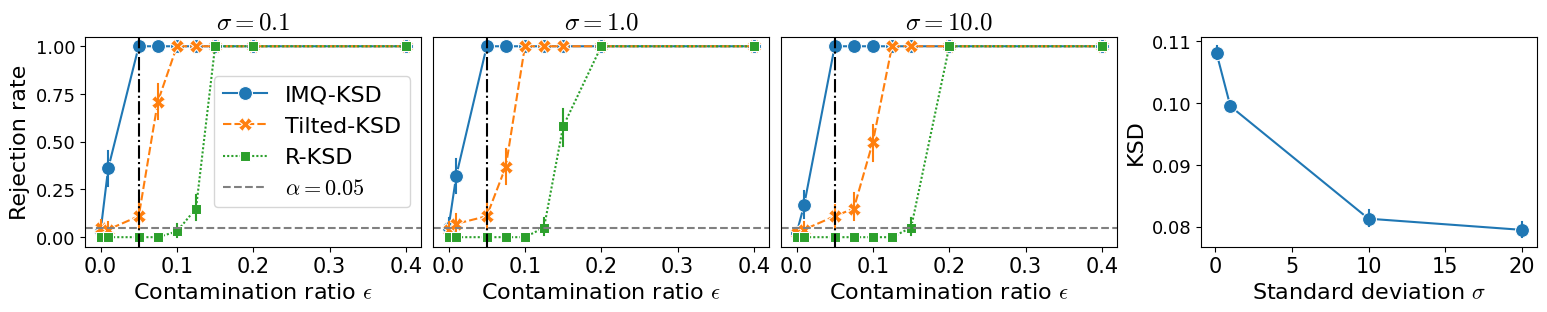

In [253]:
ol_std_ls_plot = ol_std_ls[:3]
fig = plt.figure(figsize=(4*len(ol_std_ls_plot), 3))

# Define the width of each subplot and the gap you want between subplots 2 and 3
subplot_width = 0.28
gap = 0.1

# Define positions for each subplot
positions = [
    [0.05, 0.1, subplot_width, 0.7],              # subplot 1
    [0.34, 0.1, subplot_width, 0.7],               # subplot 2
    [0.63, 0.1, subplot_width, 0.7],        # subplot 3
    [0.88 + gap, 0.1, subplot_width, 0.7],         # subplot 4
]

# Create subplots with specific positions
ax1 = fig.add_axes(positions[0])
ax2 = fig.add_axes(positions[1])
ax3 = fig.add_axes(positions[2])
ax4 = fig.add_axes(positions[3])
axes = [ax1, ax2, ax3, ax4]

for i, ol_std in enumerate(ol_std_ls_plot):
    # plot
    ax = axes[i]
    res_df_sub = res_df.loc[lambda x: x["ol_std"].eq(ol_std)]
    
    _ = sns.lineplot(
        ax=ax, data=res_df_sub, 
        x="eps", y="rej", hue="method", style="method", markers=True, err_style="bars", markersize=10,
    )
    ax.axhline(0.05, linestyle="--", color="grey", label=r"$\alpha = 0.05$")
    ax.axvline(eps0, linestyle="-.", color="k")

    ax.set_ylim(-0.05, 1.05)
    ax.tick_params(axis="both", labelsize=13)
    ax.xaxis.set_tick_params(labelsize=15)
    ax.set_xlabel(r"Contamination ratio $\epsilon$", fontsize=16)
    ax.set_ylabel("Rejection rate", fontsize=16)
    ax.set_title(rf"$\sigma={ol_std}$", fontsize=18)
    ax.legend([],[], frameon=False)
    if i > 0:
        ax.get_yaxis().set_ticks([])
        ax.set_ylabel("")

ax = axes[-1]
eps = 0.1
res_df_sub = res_df.loc[lambda x: x["eps"].eq(eps)]
_ = sns.lineplot(
    ax=ax, data=res_df_sub,
    x="ol_std", y="nonsq_stat", markers=True, style=True, err_style="bars", markersize=10,
)
ax.tick_params(axis="both", labelsize=13)
ax.xaxis.set_tick_params(labelsize=15)
ax.set_xlabel(r"Standard deviation $\sigma$", fontsize=16)
ax.set_ylabel("KSD", fontsize=16)
ax.legend([],[], frameon=False)

lgd = axes[0].legend(loc="center right", fontsize=16)
plt.tight_layout()
# plt.savefig("../figs/rej_noise.pdf", bbox_extra_artists=(lgd,), bbox_inches="tight")